# FWI · multiscale (residual-side filter)

Direct FWI on broadband data gets stuck in local minima when the
starting model is more than ~half a period off the true traveltime
(*cycle skipping*). The classic remedy is the **multiscale** strategy:
expose Adam to a low-frequency residual first, then progressively
open the bandwidth.

There are two ways to do this:

1. **Source-side multiscale (notebook-01 style):** regenerate the
   observed data with a different Ricker peak for each band — simple
   but pretends the field experiment used a different source each
   time.
2. **Residual-side multiscale (this notebook):** record one
   broadband observed dataset, then bandpass-filter **both predicted
   and observed** at FWI time so the loss only sees the chosen band.
   Matches what you actually do on real data, and the gradient flows
   cleanly through the (differentiable) FFT-based filter.

Three bands cover the spectrum: ``≤ 4 Hz``, ``≤ 8 Hz``, full band
(``≤ 25 Hz`` after the 12 Hz Ricker rolls off).


## 1. Parameters

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh = MARMOUSI_DH * 2     # 25 m
dt = 0.002
nt = 2000                # 4 s
abcn = 50
spatial_order = 8

nshots, nrec, batch_shots = 20, 200, 8
src_z, rec_z = 2, 4

# Single broadband source — Ricker at 12 Hz, used for both observed
# data generation and every FWI iteration. Bands differ only in the
# low-pass cutoff applied to syn / obs inside the loss.
freq_src, delay_src = 10.0, 0.14

bands = [
    {'f_max':  3.0, 'n_iter': 25, 'lr': 30.0},   # smooth structure (~50 m vertical resolution)
    {'f_max':  6.0, 'n_iter': 25, 'lr': 18.0},   # mid-freq
    {'f_max': 12.0, 'n_iter': 25, 'lr': 10.0},   # capped at 12 Hz so dh=25 m stays ≥ 5 ppw
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device,
      ' bands (low-pass cutoff):',
      [b['f_max'] for b in bands], 'Hz')


device: cuda  bands (low-pass cutoff): [3.0, 6.0, 12.0] Hz


## 2. Models and geometry

In [2]:
vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape = vp_true_np.shape
print('shape:', shape, '  physical:',
      f'{shape[0]*dh/1000:.1f} km × {shape[1]*dh/1000:.1f} km')

src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)
vp_true_t = torch.tensor(vp_true_np, device=device)


shape: (141, 681)   physical: 3.5 km × 17.0 km


## 3. Build the solver, broadband Ricker, observed data

Observed data are recorded **once** with the 12 Hz source. The same
wavelet is reused by every FWI iteration; only the loss-side filter
cutoff changes between bands.


In [3]:
equation = Acoustic(device=device, spatial_order=spatial_order)
solver = PropTorch(equation, shape=shape, dh=dh, dt=dt, nt=nt,
                   abcn=abcn, impl='c')
print('impl:', solver.impl, ' use_ckpt:', solver.use_ckpt)
if solver.impl == 'eager':
    batch_shots = min(batch_shots, 2)

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay_src, f=freq_src).astype(np.float32)

with torch.no_grad():
    observed = solver(wavelet, sources, receivers, models=[vp_true_t]).detach()
print('observed:', tuple(observed.shape))


impl: c  use_ckpt: False


observed: (20, 2000, 200, 1)


### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 4. Zero-phase low-pass via real FFT

Differentiable bandpass that's pure-torch (no scipy dependency, runs
on GPU): real FFT along the time axis, multiply by a cosine-tapered
spectral mask, real inverse FFT. The taper width keeps the impulse
response well-behaved compared to a hard rectangular cutoff.


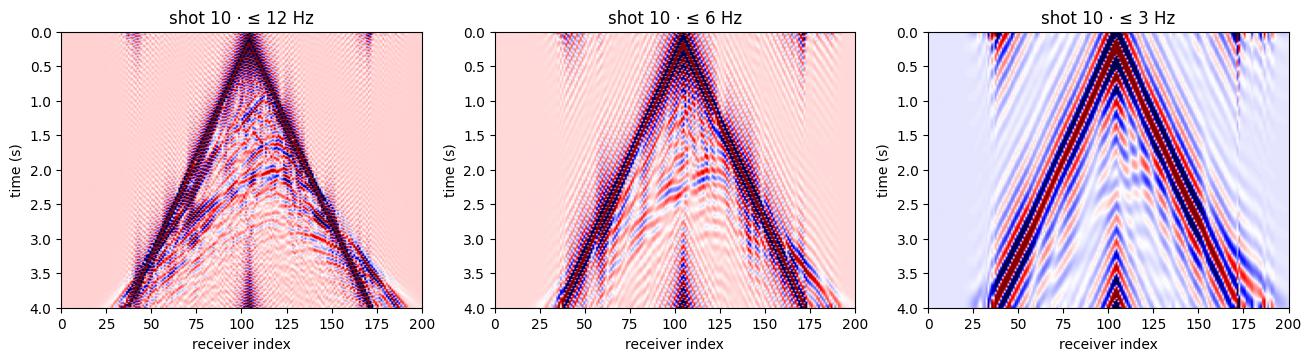

In [5]:
def lowpass_rfft(x, dt, f_max, taper_hz=0.5):
    """Zero-phase low-pass along axis 1 (the time axis) of a
    (nshots, nt, nrec, nfields) tensor. Returns ``x`` unchanged when
    ``f_max`` is None."""
    if f_max is None:
        return x
    n     = x.shape[1]
    freqs = torch.fft.rfftfreq(n, d=dt, device=x.device)
    fade_lo = f_max - taper_hz
    if fade_lo <= 0:
        fade_lo = 0.5 * f_max
    taper_w = f_max - fade_lo
    mask = torch.where(
        freqs <= fade_lo, torch.ones_like(freqs),
        torch.where(
            freqs >= f_max, torch.zeros_like(freqs),
            0.5 * (1.0 + torch.cos(np.pi * (freqs - fade_lo) / taper_w))
        )
    )
    spec = torch.fft.rfft(x, dim=1)
    spec = spec * mask.view(1, -1, 1, 1)
    return torch.fft.irfft(spec, n=n, dim=1)

# Quick sanity check: low-pass the observed gather at 4 Hz vs full band
centre = nshots // 2
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
for ax, label, panel in zip(
    axes,
    ['≤ 12 Hz', '≤ 6 Hz', '≤ 3 Hz'],
    [lowpass_rfft(observed, dt, 12.0),
     lowpass_rfft(observed, dt, 6.0),
     lowpass_rfft(observed, dt, 3.0)],
):
    g = panel[centre, :, :, 0].detach().cpu().numpy()
    vmin, vmax = np.percentile(g, [2, 98])
    ax.imshow(g, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
              extent=[0, nrec, nt * dt, 0])
    ax.set_xlabel('receiver index'); ax.set_ylabel('time (s)')
    ax.set_title(f'shot {centre} · {label}')
plt.show()


## 5. Multiscale FWI loop

For each band: bandlimit syn + obs inside the loss with the band's
cutoff, optimise the residual until ``n_iter`` is up, then open the
next band. The wavelet, solver, and observed data tensor are
unchanged across bands.


In [6]:
rng = np.random.default_rng(0)
vp_var = torch.tensor(vp_init_np, device=device, requires_grad=True)

history = []           # (band_idx, iter, loss)
stage_snapshots = [vp_var.detach().cpu().numpy().copy()]

for band_idx, band in enumerate(bands):
    f_max = band['f_max']
    optimizer = torch.optim.Adam([vp_var], lr=band['lr'], eps=1e-16)
    t_band = time.time()
    for it in range(band['n_iter']):
        idx = rng.choice(nshots, size=batch_shots, replace=False)
        optimizer.zero_grad()
        pred = solver(wavelet, sources[idx], receivers[idx],
                      models=[vp_var])
        pred_lp = lowpass_rfft(pred,            dt, f_max)
        obs_lp  = lowpass_rfft(observed[idx],   dt, f_max)
        loss = (pred_lp - obs_lp).pow(2).mean()
        loss.backward()
        optimizer.step()
        history.append((band_idx, it, float(loss.detach().cpu())))
    label = 'full' if f_max is None else f'≤ {f_max} Hz'
    print(f'band {band_idx} ({label}): {band["n_iter"]} iters in '
          f'{time.time()-t_band:.1f}s  loss '
          f'{history[-band["n_iter"]][2]:.3e} → {history[-1][2]:.3e}')
    stage_snapshots.append(vp_var.detach().cpu().numpy().copy())


band 0 (≤ 3.0 Hz): 25 iters in 20.5s  loss 4.703e-05 → 7.784e-06


band 1 (≤ 6.0 Hz): 25 iters in 20.4s  loss 4.160e-04 → 6.420e-05


band 2 (≤ 12.0 Hz): 25 iters in 20.4s  loss 2.414e-03 → 6.497e-04


## 6. Model snapshots after each band

Initial smooth → after low-band pass → after mid-band → after full
band → true (reference). The low band pulls the deep long-wavelength
structure into place; later bands sharpen interfaces.


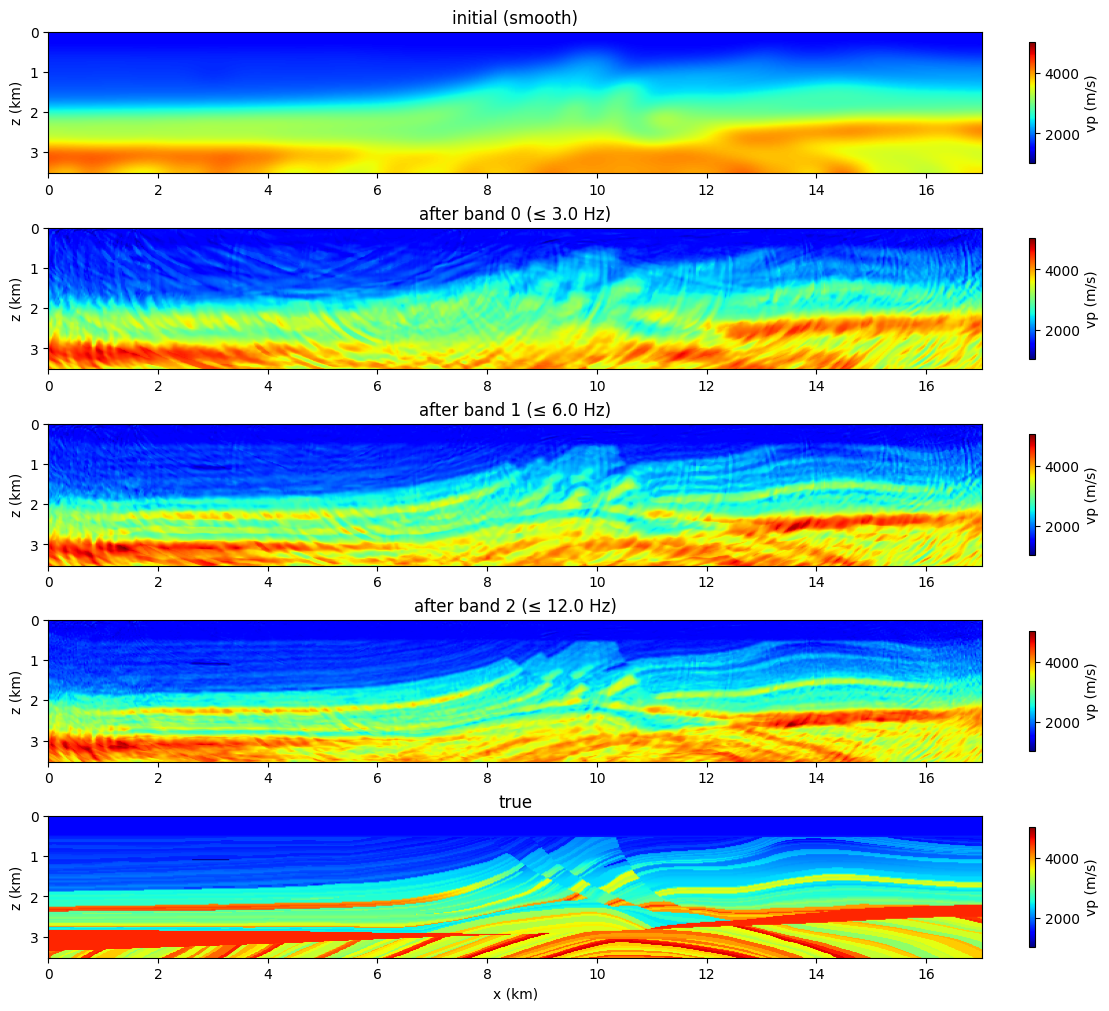

In [7]:
labels = [
    'initial (smooth)',
    *[f"after band {i} " +
       ('(full)' if b['f_max'] is None else f"(≤ {b['f_max']} Hz)")
       for i, b in enumerate(bands)],
    'true',
]
panels = [*stage_snapshots, vp_true_np]
vmin = float(min(p.min() for p in panels))
vmax = float(max(p.max() for p in panels))
fig, axes = plt.subplots(len(panels), 1, figsize=(11, 10),
                          constrained_layout=True)
for ax, label, panel in zip(axes, labels, panels):
    im = ax.imshow(panel, cmap='jet', vmin=vmin, vmax=vmax, aspect='auto',
                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
    ax.set_title(label); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, label='vp (m/s)', shrink=0.85)
axes[-1].set_xlabel('x (km)')
plt.show()


## 7. Per-band loss curves

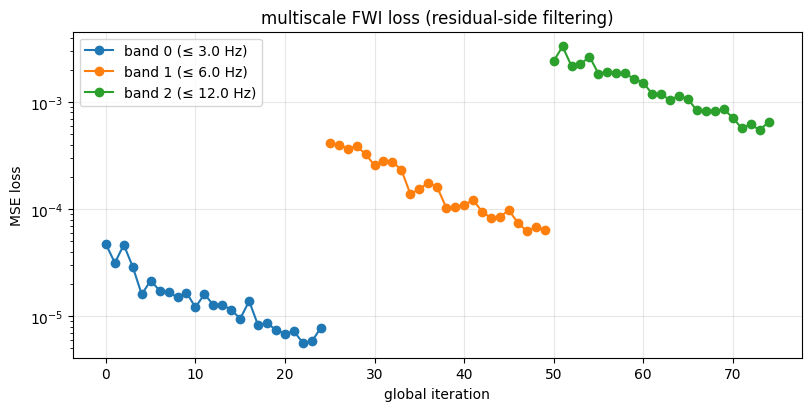

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
global_it = 0
for band_idx, band in enumerate(bands):
    sub = [h for h in history if h[0] == band_idx]
    its = np.arange(len(sub)) + global_it
    global_it += len(sub)
    label = ('full' if band['f_max'] is None else f"≤ {band['f_max']} Hz")
    ax.plot(its, [h[2] for h in sub], marker='o', label=f'band {band_idx} ({label})')
ax.set_xlabel('global iteration'); ax.set_ylabel('MSE loss')
ax.set_yscale('log'); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('multiscale FWI loss (residual-side filtering)')
plt.show()


## Reference

Bunks, C., Saleck, F. M., Zaleski, S., & Chavent, G. (1995). Multiscale seismic waveform inversion. *Geophysics, 60*(5), 1457–1473. [doi:10.1190/1.1443880](https://doi.org/10.1190/1.1443880) — the multiscale (frequency-continuation) waveform inversion demonstrated here.

---

<p><strong>Download this notebook</strong> &mdash; <a href="03_fwi_multiscale.ipynb" download><code>03_fwi_multiscale.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/03_fwi_multiscale.ipynb">view on GitHub</a></p>
